In [2]:
import pandas as pd

In [ ]:
df = pd.read_csv("planilhas/placas_lidas_melhor_1_avaliacao_por_letra.csv")

df_ = df.drop(columns=["arquivo"])
df_

In [8]:
import pandas as pd

df_ = pd.read_csv("planilhas/placas_lidas_melhor_1_avaliacao_por_letra.csv")

#df = df.drop(columns=["arquivo"])

# garantir tipos
df["frame"] = pd.to_numeric(df["frame"], errors="coerce")
df["acerto_por_letra"] = pd.to_numeric(df["acerto_por_letra"], errors="coerce")
df["conf_media"] = pd.to_numeric(df["conf_media"], errors="coerce")

# normalizar textos para comparação da placa completa
def limpar(s): 
    return str(s).strip().upper()

df["gt"] = df["gt"].apply(limpar)
df["pred"] = df["pred"].apply(limpar)
df["acerto_placa"] = (df["gt"] == df["pred"]).astype(int)

# === definir intervalos (id, início, fim, rótulo) ===
intervalos = [
    (0,   0,  19,  "0-19"),
    (1, 101, 117, "101-117"),
    (2, 118, 145, "118-145"),
    (3, 146, 160, "146-160"),
    (4, 161, 183, "161-183"),
    (5, 184, 202, "184-202"),
    (6, 203, 224, "203-224"),
    (7,  21,  42,   "21-42"),
    (8, 225, 243, "225-243"),
    (9, 244, 258, "244-258"),
]

def map_intervalo(frame):
    for _, ini, fim, lbl in intervalos:
        if pd.notna(frame) and ini <= frame <= fim:
            return lbl
    return None

df["intervalo"] = df["frame"].apply(map_intervalo)
df = df.dropna(subset=["intervalo"]).copy()

# === métricas globais (em %) ===
acc_letra_global = df["acerto_por_letra"].mean() * 100
acc_placa_global = df["acerto_placa"].mean() * 100

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# === métricas por intervalo ===
def agrega(g):
    return pd.Series({
        "acc_letra": g["acerto_por_letra"].mean() * 100,  # %
        "acc_placa": g["acerto_placa"].mean() * 100,      # %
        "n": len(g)
    })

tabela = (
    df.groupby("intervalo", as_index=False)
      .apply(agrega)
      .reset_index(drop=True)
)

# ordenar pela ordem desejada (0..9) usando o vetor acima
ordem = [lbl for *_, lbl in intervalos]
tabela["ordem"] = tabela["intervalo"].apply(lambda x: ordem.index(x))
tabela = tabela.sort_values("ordem").drop(columns="ordem")

# imprimir tabela no formato solicitado
print("  intervalo  acc_letra  acc_placa  n")
for _, row in tabela.iterrows():
    print(f"{row['intervalo']:>9}  {row['acc_letra']:>9.2f}  {row['acc_placa']:>9.1f}  {int(row['n'])}")

# === filtro por confiança (>= 0.50) ===
filtro = df[df["conf_media"] >= 0.50]
acc_letra_filtrada = filtro["acerto_por_letra"].mean() * 100
acc_placa_filtrada = filtro["acerto_placa"].mean() * 100

print("\nCom filtro de confiança OCR >= 0.50")
print(f"Acurácia por letra: {acc_letra_filtrada:.3f}")
print(f"Acurácia de placa: {acc_placa_filtrada:.1f}")


Acurácia por letra (global): 57.464
Acurácia de placa (global): 35.000
  intervalo  acc_letra  acc_placa  n
     0-19      67.50        0.0  20
  101-117      47.06        0.0  17
  118-145     100.00      100.0  28
  146-160      70.48        0.0  15
  161-183     100.00      100.0  23
  184-202       0.00        0.0  19
  203-224       0.00        0.0  22
    21-42       0.00        0.0  22
  225-243     100.00      100.0  19
  244-258      85.71        0.0  15

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 83.077
Acurácia de placa: 71.8


C:\Users\isabel_martins\AppData\Local\Temp\ipykernel_25376\1795040592.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("intervalo", as_index=False)


In [9]:
import pandas as pd

df_ = pd.read_csv("planilhas\placas_lidas_margem_oito.csv")

#df = df.drop(columns=["arquivo"])

# garantir tipos
df["frame"] = pd.to_numeric(df["frame"], errors="coerce")
df["acerto_por_letra"] = pd.to_numeric(df["acerto_por_letra"], errors="coerce")
df["conf_media"] = pd.to_numeric(df["conf_media"], errors="coerce")

# normalizar textos para comparação da placa completa
def limpar(s): 
    return str(s).strip().upper()

df["gt"] = df["gt"].apply(limpar)
df["pred"] = df["pred"].apply(limpar)
df["acerto_placa"] = (df["gt"] == df["pred"]).astype(int)

# === definir intervalos (id, início, fim, rótulo) ===
intervalos = [
    (0,   0,  19,  "0-19"),
    (1, 101, 117, "101-117"),
    (2, 118, 145, "118-145"),
    (3, 146, 160, "146-160"),
    (4, 161, 183, "161-183"),
    (5, 184, 202, "184-202"),
    (6, 203, 224, "203-224"),
    (7,  21,  42,   "21-42"),
    (8, 225, 243, "225-243"),
    (9, 244, 258, "244-258"),
]

def map_intervalo(frame):
    for _, ini, fim, lbl in intervalos:
        if pd.notna(frame) and ini <= frame <= fim:
            return lbl
    return None

df["intervalo"] = df["frame"].apply(map_intervalo)
df = df.dropna(subset=["intervalo"]).copy()

# === métricas globais (em %) ===
acc_letra_global = df["acerto_por_letra"].mean() * 100
acc_placa_global = df["acerto_placa"].mean() * 100

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# === métricas por intervalo ===
def agrega(g):
    return pd.Series({
        "acc_letra": g["acerto_por_letra"].mean() * 100,  # %
        "acc_placa": g["acerto_placa"].mean() * 100,      # %
        "n": len(g)
    })

tabela = (
    df.groupby("intervalo", as_index=False)
      .apply(agrega)
      .reset_index(drop=True)
)

# ordenar pela ordem desejada (0..9) usando o vetor acima
ordem = [lbl for *_, lbl in intervalos]
tabela["ordem"] = tabela["intervalo"].apply(lambda x: ordem.index(x))
tabela = tabela.sort_values("ordem").drop(columns="ordem")

# imprimir tabela no formato solicitado
print("  intervalo  acc_letra  acc_placa  n")
for _, row in tabela.iterrows():
    print(f"{row['intervalo']:>9}  {row['acc_letra']:>9.2f}  {row['acc_placa']:>9.1f}  {int(row['n'])}")

# === filtro por confiança (>= 0.50) ===
filtro = df[df["conf_media"] >= 0.50]
acc_letra_filtrada = filtro["acerto_por_letra"].mean() * 100
acc_placa_filtrada = filtro["acerto_placa"].mean() * 100

print("\nCom filtro de confiança OCR >= 0.50")
print(f"Acurácia por letra: {acc_letra_filtrada:.3f}")
print(f"Acurácia de placa: {acc_placa_filtrada:.1f}")

Acurácia por letra (global): 57.464
Acurácia de placa (global): 35.000
  intervalo  acc_letra  acc_placa  n
     0-19      67.50        0.0  20
  101-117      47.06        0.0  17
  118-145     100.00      100.0  28
  146-160      70.48        0.0  15
  161-183     100.00      100.0  23
  184-202       0.00        0.0  19
  203-224       0.00        0.0  22
    21-42       0.00        0.0  22
  225-243     100.00      100.0  19
  244-258      85.71        0.0  15

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 83.077
Acurácia de placa: 71.8


C:\Users\isabel_martins\AppData\Local\Temp\ipykernel_25376\3061341287.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("intervalo", as_index=False)


In [10]:
import pandas as pd

df_ = pd.read_csv("planilhas\placas_lidas_melhor_1_margem_justa.csv")

#df = df.drop(columns=["arquivo"])

# garantir tipos
df["frame"] = pd.to_numeric(df["frame"], errors="coerce")
df["acerto_por_letra"] = pd.to_numeric(df["acerto_por_letra"], errors="coerce")
df["conf_media"] = pd.to_numeric(df["conf_media"], errors="coerce")

# normalizar textos para comparação da placa completa
def limpar(s): 
    return str(s).strip().upper()

df["gt"] = df["gt"].apply(limpar)
df["pred"] = df["pred"].apply(limpar)
df["acerto_placa"] = (df["gt"] == df["pred"]).astype(int)

# === definir intervalos (id, início, fim, rótulo) ===
intervalos = [
    (0,   0,  19,  "0-19"),
    (1, 101, 117, "101-117"),
    (2, 118, 145, "118-145"),
    (3, 146, 160, "146-160"),
    (4, 161, 183, "161-183"),
    (5, 184, 202, "184-202"),
    (6, 203, 224, "203-224"),
    (7,  21,  42,   "21-42"),
    (8, 225, 243, "225-243"),
    (9, 244, 258, "244-258"),
]

def map_intervalo(frame):
    for _, ini, fim, lbl in intervalos:
        if pd.notna(frame) and ini <= frame <= fim:
            return lbl
    return None

df["intervalo"] = df["frame"].apply(map_intervalo)
df = df.dropna(subset=["intervalo"]).copy()

# === métricas globais (em %) ===
acc_letra_global = df["acerto_por_letra"].mean() * 100
acc_placa_global = df["acerto_placa"].mean() * 100

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# === métricas por intervalo ===
def agrega(g):
    return pd.Series({
        "acc_letra": g["acerto_por_letra"].mean() * 100,  # %
        "acc_placa": g["acerto_placa"].mean() * 100,      # %
        "n": len(g)
    })

tabela = (
    df.groupby("intervalo", as_index=False)
      .apply(agrega)
      .reset_index(drop=True)
)

# ordenar pela ordem desejada (0..9) usando o vetor acima
ordem = [lbl for *_, lbl in intervalos]
tabela["ordem"] = tabela["intervalo"].apply(lambda x: ordem.index(x))
tabela = tabela.sort_values("ordem").drop(columns="ordem")

# imprimir tabela no formato solicitado
print("  intervalo  acc_letra  acc_placa  n")
for _, row in tabela.iterrows():
    print(f"{row['intervalo']:>9}  {row['acc_letra']:>9.2f}  {row['acc_placa']:>9.1f}  {int(row['n'])}")

# === filtro por confiança (>= 0.50) ===
filtro = df[df["conf_media"] >= 0.50]
acc_letra_filtrada = filtro["acerto_por_letra"].mean() * 100
acc_placa_filtrada = filtro["acerto_placa"].mean() * 100

print("\nCom filtro de confiança OCR >= 0.50")
print(f"Acurácia por letra: {acc_letra_filtrada:.3f}")
print(f"Acurácia de placa: {acc_placa_filtrada:.1f}")

Acurácia por letra (global): 57.464
Acurácia de placa (global): 35.000
  intervalo  acc_letra  acc_placa  n
     0-19      67.50        0.0  20
  101-117      47.06        0.0  17
  118-145     100.00      100.0  28
  146-160      70.48        0.0  15
  161-183     100.00      100.0  23
  184-202       0.00        0.0  19
  203-224       0.00        0.0  22
    21-42       0.00        0.0  22
  225-243     100.00      100.0  19
  244-258      85.71        0.0  15

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 83.077
Acurácia de placa: 71.8


C:\Users\isabel_martins\AppData\Local\Temp\ipykernel_25376\2190511622.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("intervalo", as_index=False)


## Tesseract - configuração agressiva

In [20]:
import pandas as pd

tesseract_tres = pd.read_csv("resul_JUSTO.csv")

tesseract_tres.head(20)

,pasta_origem,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,recorte_justo,0-19,HONDUH,HONDUH,HONDUH,-0.008,100.00,100.0
1,recorte_justo,0-19,HONDUH,HONDUH,HONDUH,-0.008,100.00,100.0
2,recorte_justo,21-42,TIMELESS,TIMELESS,TIMELESS,0.068,100.00,100.0
3,recorte_justo,21-42,THELESS,THELESS,TIMELESS,0.052,25.00,0.0
4,recorte_justo,43-60,EEWABG,EEWABG,EEWABUG,-0.008,71.43,0.0
5,recorte_justo,43-60,EEWABG,EEWABG,EEWABUG,-0.008,71.43,0.0
6,recorte_justo,61-79,PIKACHU,PIKACHU,PIKACHU,-0.008,100.00,100.0
7,recorte_justo,61-79,PIKACHU,PIKACHU,PIKACHU,-0.008,100.00,100.0
8,recorte_justo,80-100,NaN,NaN,OHIFIT,-0.010,0.00,0.0
9,recorte_justo,80-100,NaN,NaN,OHIFIT,-0.010,0.00,0.0


In [21]:
df = pd.read_csv("resul_JUSTO.csv")

# assegure tipos numéricos
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()
#acc_hibrida_global = df["confianca_placa_produto"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")
#print(f"Métrica híbrida (global): {acc_hibrida_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = df.groupby("intervalo").agg(
    acc_letra=("confianca_letras","mean"),
    acc_placa=("confianca_placa","mean"),
    #acc_hibrida=("confianca_placa_produto","mean"),
    n=("confianca_letras","size")
).reset_index()

print(por_intervalo.head(10))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 58.750
Acurácia de placa (global): 42.857
  intervalo  acc_letra  acc_placa  n
0      0-19     100.00      100.0  2
1   101-117      10.00        0.0  2
2   118-145     100.00      100.0  2
3   146-160       0.00        0.0  2
4   161-183     100.00      100.0  2
5   184-202      57.14        0.0  2
6   203-224       0.00        0.0  2
7     21-42      62.50       50.0  2
8   225-243     100.00      100.0  2
9   244-258      50.00       50.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: nan
Acurácia de placa: nan


## Tesseract + Justo + cor


In [ ]:
import pandas as pd
from pathlib import Path

resultado_easy = Path(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_COR.csv")
df = pd.read_csv(resultado_easy)
df.head(30)

In [25]:
df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HONDUH,HONDUH,HONDUH,0.00,100.0,100.0
2,21-42,TIMELESS,TIMELESS,TIMELESS,0.88,100.0,100.0
4,43-60,EEWABLIG,EEWABLIG,EEWABUG,0.00,75.0,0.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.96,100.0,100.0
8,80-100,NaN,NaN,OHIFIT,0.00,0.0,0.0
10,101-117,ACS,ACS,EWGAS,0.00,20.0,0.0
12,118-145,OF ZELDA,OFZELDA,OFZELDA,0.59,100.0,100.0
14,146-160,JBYE401K,JBYE401K,BYE4O1K,0.00,75.0,0.0
16,161-183,MUAHAHA,MUAHAHA,MUAHAHA,0.00,100.0,100.0
18,184-202,NaN,NaN,ORINNIE,0.00,0.0,0.0


In [27]:
#resultado_easy = Path(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_COR.csv")
#df = pd.read_csv(resultado_easy)
#df.head(30)

#df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
#df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_COR.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 47.857
Acurácia de placa (global): 35.714

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19      100.0      100.0  2
    21-42      100.0      100.0  2
    43-60       75.0        0.0  2
    61-79      100.0      100.0  2
   80-100        0.0        0.0  2
  101-117       20.0        0.0  2
  118-145      100.0      100.0  2
  146-160       75.0        0.0  2
  161-183      100.0      100.0  2
  184-202        0.0        0.0  2
  203-224        0.0        0.0  2
  225-243        0.0        0.0  2
  244-258        0.0        0.0  2
  259-307        0.0        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 100.0
Acurácia de placa: 100.0


## Tesseract + Justo + ADAPT

In [ ]:
resultado_TESS = Path(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_ADAPT.csv")
df = pd.read_csv(resultado_TESS)
df.head(30)

In [29]:
df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,NaN,NaN,HONDUH,0.0,0.0,0.0
2,21-42,NaN,NaN,TIMELESS,0.0,0.0,0.0
4,43-60,NaN,NaN,EEWABUG,0.0,0.0,0.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.0,100.0,100.0
8,80-100,NaN,NaN,OHIFIT,0.0,0.0,0.0
10,101-117,EIS,EIS,EWGAS,0.0,40.0,0.0
12,118-145,OFZELDA,OFZELDA,OFZELDA,0.0,100.0,100.0
14,146-160,NaN,NaN,BYE4O1K,0.0,0.0,0.0
16,161-183,NaN,NaN,MUAHAHA,0.0,0.0,0.0
18,184-202,NaN,NaN,ORINNIE,0.0,0.0,0.0


In [30]:
#resultado_easy = Path(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_ADAPT.csv")
#df = pd.read_csv(resultado_easy)
#df.head(30)

#df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
#df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_ADAPT.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 24.286
Acurácia de placa (global): 21.429

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19        0.0        0.0  2
    21-42        0.0        0.0  2
    43-60        0.0        0.0  2
    61-79      100.0      100.0  2
   80-100        0.0        0.0  2
  101-117       40.0        0.0  2
  118-145      100.0      100.0  2
  146-160        0.0        0.0  2
  161-183        0.0        0.0  2
  184-202        0.0        0.0  2
  203-224      100.0      100.0  2
  225-243        0.0        0.0  2
  244-258        0.0        0.0  2
  259-307        0.0        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: nan
Acurácia de placa: nan


## Tesseract + justo + Otsu

In [ ]:
resultado_tess = Path(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_OTSU.csv")
df = pd.read_csv(resultado_tess)
df.head(30)

In [32]:
df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HONDUH,HONDUH,HONDUH,0.00,100.00,100.0
2,21-42,NaN,NaN,TIMELESS,0.00,0.00,0.0
4,43-60,NaN,NaN,EEWABUG,0.00,0.00,0.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.95,100.00,100.0
8,80-100,NaN,NaN,OHIFIT,0.00,0.00,0.0
10,101-117,NaN,NaN,EWGAS,0.00,0.00,0.0
12,118-145,NaN,NaN,OFZELDA,0.00,0.00,0.0
14,146-160,IBYE401K,IBYE401K,BYE4O1K,0.00,75.00,0.0
16,161-183,NUAHAHA,NUAHAHA,MUAHAHA,0.00,85.71,0.0
18,184-202,NaN,NaN,ORINNIE,0.00,0.00,0.0


In [33]:
#resultado_TESS = Path(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_ADAPT.csv")
#df = pd.read_csv(resultado_TESS)
#df.head(30)

#df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
#df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_OTSU.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 25.319
Acurácia de placa (global): 14.286

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19     100.00      100.0  2
    21-42       0.00        0.0  2
    43-60       0.00        0.0  2
    61-79     100.00      100.0  2
   80-100       0.00        0.0  2
  101-117       0.00        0.0  2
  118-145       0.00        0.0  2
  146-160      68.75        0.0  2
  161-183      85.71        0.0  2
  184-202       0.00        0.0  2
  203-224       0.00        0.0  2
  225-243       0.00        0.0  2
  244-258       0.00        0.0  2
  259-307       0.00        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 100.0
Acurácia de placa: 100.0


## Tesseract Específico + justo + cor

In [ ]:
resultado_TESS = Path(r"runs\detect\placas_varios_recortes\resul_TESS_DOIS_JUSTO_COR.csv")
df = pd.read_csv(resultado_TESS)
df.head(30)



In [35]:
df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HONDUH,HONDUH,HONDUH,0.0,100.00,100.0
2,21-42,THELESS,THELESS,TIMELESS,0.3,75.00,0.0
4,43-60,EEWABUG,EEWABUG,EEWABUG,0.0,100.00,100.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.0,100.00,100.0
8,80-100,NaN,NaN,OHIFIT,0.0,0.00,0.0
10,101-117,EUS,EUS,EWGAS,0.0,40.00,0.0
12,118-145,OFZELDA,OFZELDA,OFZELDA,0.0,100.00,100.0
14,146-160,JBYE401K,JBYE401K,BYE4O1K,0.0,75.00,0.0
16,161-183,MUAHAHA,MUAHAHA,MUAHAHA,0.0,100.00,100.0
18,184-202,ORTHNTE,ORTHNTE,ORINNIE,0.0,57.14,0.0


In [36]:
#resultado_TESS = Path(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_ADAPT.csv")
#df = pd.read_csv(resultado_TESS)
#df.head(30)

#df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
#df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv(r"runs\detect\placas_varios_recortes\resul_TESS_DOIS_JUSTO_COR.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 78.084
Acurácia de placa (global): 46.429

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19    100.000      100.0  2
    21-42     75.000        0.0  2
    43-60     92.855       50.0  2
    61-79    100.000      100.0  2
   80-100      0.000        0.0  2
  101-117     40.000        0.0  2
  118-145    100.000      100.0  2
  146-160     75.000        0.0  2
  161-183    100.000      100.0  2
  184-202     57.140        0.0  2
  203-224     81.745        0.0  2
  225-243    100.000      100.0  2
  244-258    100.000      100.0  2
  259-307     71.430        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: nan
Acurácia de placa: nan


## Tesseract específico + justo + adapt

In [37]:
resultado_TESS = Path(r"runs\detect\placas_varios_recortes\resul_TESS_DOIS_JUSTO_ADAPT.csv")
df = pd.read_csv(resultado_TESS)
#df.head(30)



In [38]:
df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HONDUH,HONDUH,HONDUH,0.00,100.00,100.0
2,21-42,TIMELESS,TIMELESS,TIMELESS,0.19,100.00,100.0
4,43-60,EEWABUG,EEWABUG,EEWABUG,0.00,100.00,100.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.00,100.00,100.0
8,80-100,NaN,NaN,OHIFIT,0.00,0.00,0.0
10,101-117,EIS,EIS,EWGAS,0.00,40.00,0.0
12,118-145,OFZELDA,OFZELDA,OFZELDA,0.00,100.00,100.0
14,146-160,JBYE401K,JBYE401K,BYE4O1K,0.00,75.00,0.0
16,161-183,RUAHAH,RUAHAH,MUAHAHA,0.00,71.43,0.0
18,184-202,TN,TN,ORINNIE,0.00,14.29,0.0


In [39]:
#resultado_TESS = Path(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_ADAPT.csv")
#df = pd.read_csv(resultado_TESS)
#df.head(30)

#df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
#df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv(r"runs\detect\placas_varios_recortes\resul_TESS_DOIS_JUSTO_ADAPT.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 73.521
Acurácia de placa (global): 50.000

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19     100.00      100.0  2
    21-42     100.00      100.0  2
    43-60     100.00      100.0  2
    61-79     100.00      100.0  2
   80-100       0.00        0.0  2
  101-117      40.00        0.0  2
  118-145     100.00      100.0  2
  146-160      75.00        0.0  2
  161-183      71.43        0.0  2
  184-202      14.29        0.0  2
  203-224     100.00      100.0  2
  225-243     100.00      100.0  2
  244-258      85.71        0.0  2
  259-307      42.86        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: nan
Acurácia de placa: nan


## Tesseract Específico + justo + Otsu

In [40]:
resultado_TESS = Path(r"runs\detect\placas_varios_recortes\resul_TESS_DOIS_JUSTO_OTSU.csv")
df = pd.read_csv(resultado_TESS)
#df.head(30)



In [41]:
df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HONDUH,HONDUH,HONDUH,0.00,100.00,100.0
2,21-42,TIMELESS,TIMELESS,TIMELESS,0.50,100.00,100.0
4,43-60,EEKABUG,EEKABUG,EEWABUG,0.00,85.71,0.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.00,100.00,100.0
8,80-100,NaN,NaN,OHIFIT,0.00,0.00,0.0
10,101-117,OGIS,OGIS,EWGAS,0.00,40.00,0.0
12,118-145,OFZELDA,OFZELDA,OFZELDA,0.00,100.00,100.0
14,146-160,IBYE401K,IBYE401K,BYE4O1K,0.00,75.00,0.0
16,161-183,NUAHAHA,NUAHAHA,MUAHAHA,0.00,85.71,0.0
18,184-202,ORTANTE,ORTANTE,ORINNIE,0.00,57.14,0.0


In [42]:
#resultado_TESS = Path(r"runs\detect\placas_varios_recortes\resul_TESS_UM_JUSTO_ADAPT.csv")
#df = pd.read_csv(resultado_TESS)
#df.head(30)

#df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
#df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv(r"runs\detect\placas_varios_recortes\resul_TESS_DOIS_JUSTO_OTSU.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 72.125
Acurácia de placa (global): 42.857

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19     100.00      100.0  2
    21-42     100.00      100.0  2
    43-60      85.71        0.0  2
    61-79     100.00      100.0  2
   80-100       0.00        0.0  2
  101-117      30.00        0.0  2
  118-145     100.00      100.0  2
  146-160      75.00        0.0  2
  161-183      85.71        0.0  2
  184-202      57.14        0.0  2
  203-224      76.19        0.0  2
  225-243     100.00      100.0  2
  244-258     100.00      100.0  2
  259-307       0.00        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 100.0
Acurácia de placa: 100.0


Salvo: acuracia_por_letra_barras.png, acuracia_por_placa_barras.png


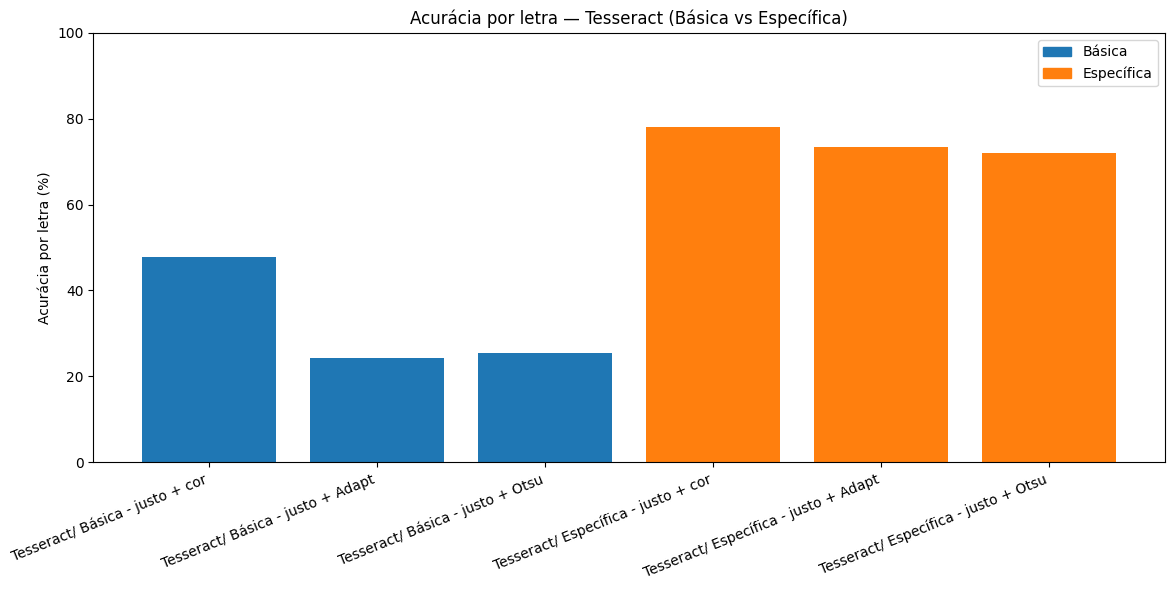

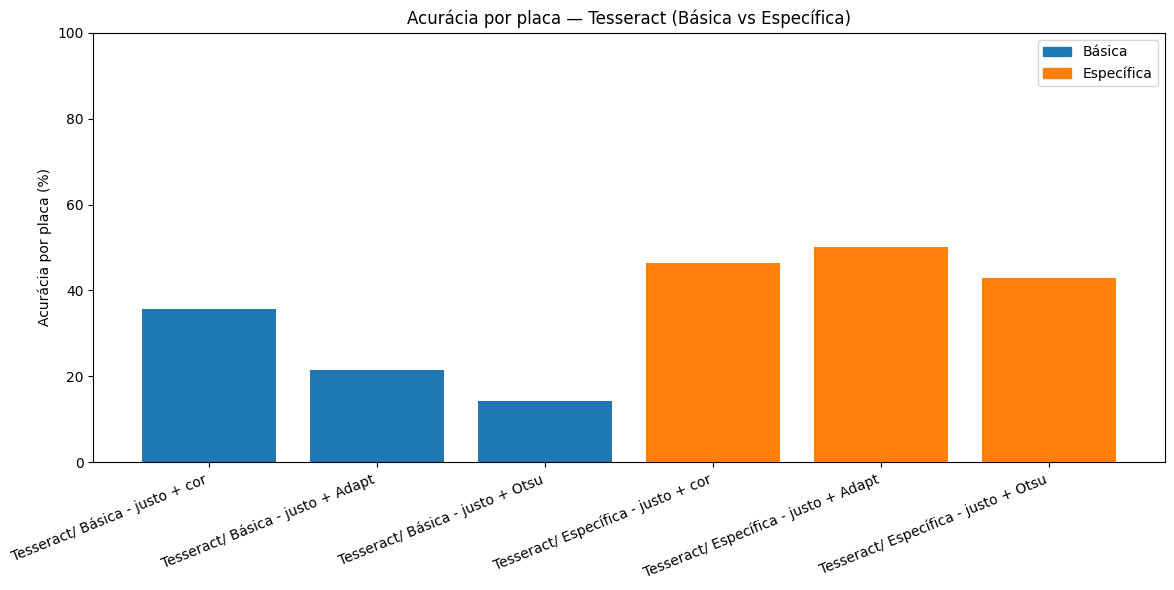

In [43]:
# salvar como plot_tesseract_barras.py
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --------- dados ---------
rows = [
    {"nome": "Tesseract/ Básica - justo + cor",   "tipo": "Básica",      "acc_letra": 47.85, "acc_placa": 35.71},
    {"nome": "Tesseract/ Básica - justo + Adapt", "tipo": "Básica",      "acc_letra": 24.28, "acc_placa": 21.42},
    {"nome": "Tesseract/ Básica - justo + Otsu",  "tipo": "Básica",      "acc_letra": 25.31, "acc_placa": 14.28},
    {"nome": "Tesseract/ Específica - justo + cor",   "tipo": "Específica",  "acc_letra": 78.00, "acc_placa": 46.42},
    {"nome": "Tesseract/ Específica - justo + Adapt", "tipo": "Específica",  "acc_letra": 73.52, "acc_placa": 50.00},
    {"nome": "Tesseract/ Específica - justo + Otsu",  "tipo": "Específica",  "acc_letra": 72.12, "acc_placa": 42.85},
]
df = pd.DataFrame(rows)

# --------- cores ---------
color_map = {"Básica": "#1f77b4", "Específica": "#ff7f0e"}
bar_colors = [color_map[t] for t in df["tipo"]]
legend_handles = [Patch(color=color_map["Básica"], label="Básica"),
                  Patch(color=color_map["Específica"], label="Específica")]

def plot_metric(metric_col: str, title: str, out_png: str):
    plt.figure(figsize=(12, 6))
    plt.bar(df["nome"], df[metric_col], color=bar_colors)
    plt.xticks(rotation=22, ha="right")
    ylabel = "Acurácia por letra (%)" if metric_col == "acc_letra" else "Acurácia por placa (%)"
    plt.ylabel(ylabel)
    plt.title(title)
    plt.ylim(0, 100)
    plt.legend(handles=legend_handles, loc="upper right")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    # plt.show()  # descomente se quiser visualizar na hora

if __name__ == "__main__":
    plot_metric("acc_letra",
                "Acurácia por letra — Tesseract (Básica vs Específica)",
                "acuracia_por_letra_barras.png")
    plot_metric("acc_placa",
                "Acurácia por placa — Tesseract (Básica vs Específica)",
                "acuracia_por_placa_barras.png")
    print("Salvo: acuracia_por_letra_barras.png, acuracia_por_placa_barras.png")
